In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier

import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("cardio_features_full.csv")

df.head()

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,bmi_category,obesity,bp_category,hypertension,metabolic_risk,lifestyle_risk,risk_score
0,50,2,168,62.0,110,80,1,1,0,0,1,0,21.967120,normal,0,hipertension_etapa_1,1,0,0,1
1,55,1,156,85.0,140,90,3,1,0,0,1,1,34.927679,obesidad,1,hipertension_etapa_2,1,1,0,3
2,51,1,165,64.0,130,70,3,1,0,0,0,1,23.507805,normal,0,hipertension_etapa_1,1,1,1,3
3,48,2,169,82.0,150,100,1,1,0,0,1,1,28.710479,sobrepeso,0,hipertension_etapa_2,1,0,0,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0,23.011177,normal,0,normal,0,0,1,1


In [3]:
df = pd.read_csv("cardio_features_full.csv")

df.head()

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,bmi_category,obesity,bp_category,hypertension,metabolic_risk,lifestyle_risk,risk_score
0,50,2,168,62.0,110,80,1,1,0,0,1,0,21.967120,normal,0,hipertension_etapa_1,1,0,0,1
1,55,1,156,85.0,140,90,3,1,0,0,1,1,34.927679,obesidad,1,hipertension_etapa_2,1,1,0,3
2,51,1,165,64.0,130,70,3,1,0,0,0,1,23.507805,normal,0,hipertension_etapa_1,1,1,1,3
3,48,2,169,82.0,150,100,1,1,0,0,1,1,28.710479,sobrepeso,0,hipertension_etapa_2,1,0,0,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0,23.011177,normal,0,normal,0,0,1,1


## separar x y

In [4]:
X = df.drop("cardio", axis=1)
y = df["cardio"]

In [5]:
## identificar variables numéricas y categóricas
columnas_numericas = X.select_dtypes(include=["int64", "float64"]).columns
columnas_categoricas = X.select_dtypes(include=["object", "category"]).columns

print("Numéricas:")
print(columnas_numericas)

print("\nCategóricas:")
print(columnas_categoricas)

Numéricas:
Index(['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'obesity',
       'hypertension', 'metabolic_risk', 'lifestyle_risk', 'risk_score'],
      dtype='str')

Categóricas:
Index(['bmi_category', 'bp_category'], dtype='str')


C:\Users\igorc\AppData\Local\Temp\ipykernel_14348\370091952.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = X.select_dtypes(include=["object", "category"]).columns


## separar entrenamiento y prueba

In [6]:
# separar en train y test en 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
print("Distribución entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución prueba:")
print(y_test.value_counts(normalize=True))

Distribución entrenamiento:
cardio
0    0.505318
1    0.494682
Name: proportion, dtype: float64

Distribución prueba:
cardio
0    0.505318
1    0.494682
Name: proportion, dtype: float64


In [8]:
# crear tabla con las proporciones que ya imprimiste
dist_train = y_train.value_counts(normalize=True).sort_index()
dist_test = y_test.value_counts(normalize=True).sort_index()

distribucion = pd.DataFrame({
    "Entrenamiento": dist_train,
    "Prueba": dist_test
})

distribucion.index = ["No cardio", "Cardio"]

distribucion

,Entrenamiento,Prueba
No cardio,0.505318,0.505318
Cardio,0.494682,0.494682


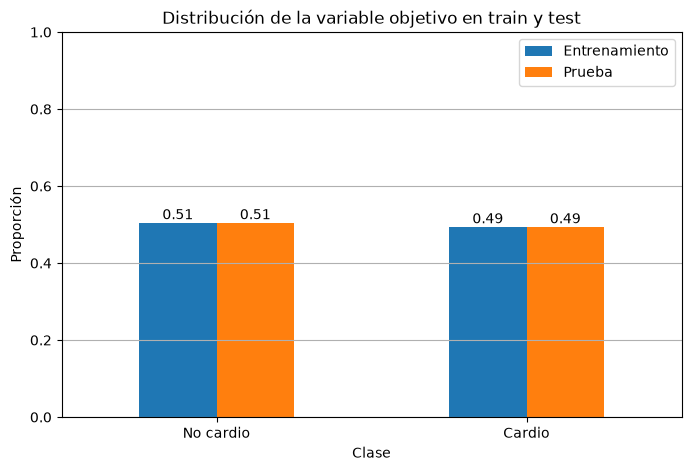

In [9]:
ax = distribucion.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribución de la variable objetivo en train y test")
plt.xlabel("Clase")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y")

# mostrar valores encima de las barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.show()

## preprocesamiento

In [10]:
# preprocesamiento para variables numéricas y categóricas
preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas), # estandarizar numéricas
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas) # codificar categóricas
    ]
)

## Comparacion de modelos

In [13]:
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [26]:
resultados = []
probabilidades_modelos = {}

for nombre, modelo in modelos.items():

    print("Entrenando:", nombre)

    pipeline = Pipeline(steps=[
        ("preprocesamiento", preprocesamiento),
        ("modelo", modelo)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    probabilidades_modelos[nombre] = y_proba

    matriz = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = matriz.ravel()

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

df_resultados = pd.DataFrame(resultados)

df_resultados.round(4)

Entrenando: Regresión Logística
Entrenando: KNN
Entrenando: Árbol de Decisión
Entrenando: Random Forest
Entrenando: SVM


c:\Users\igorc\OneDrive\Documentos\ana_cabrera\IA 3er semestre\ADQISICION, ANALISIS Y PROCESAMIENTO DE DATOS\PROYECTO_FINAL_2\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Entrenando: Naive Bayes
Entrenando: Gradient Boosting


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Regresión Logística,0.7276,0.7589,0.6585,0.7051,0.7936,5516,1421,2319,4472
1,KNN,0.6887,0.6920,0.6681,0.6799,0.7405,4918,2019,2254,4537
2,Árbol de Decisión,0.6277,0.6261,0.6142,0.6201,0.6291,4446,2491,2620,4171
3,Random Forest,0.7043,0.7045,0.6927,0.6985,0.7632,4964,1973,2087,4704
4,SVM,0.7292,0.7542,0.6715,0.7104,0.7855,5451,1486,2231,4560
5,Naive Bayes,0.6866,0.6858,0.6760,0.6809,0.7513,4834,2103,2200,4591
6,Gradient Boosting,0.7304,0.7452,0.6915,0.7173,0.8022,5331,1606,2095,4696


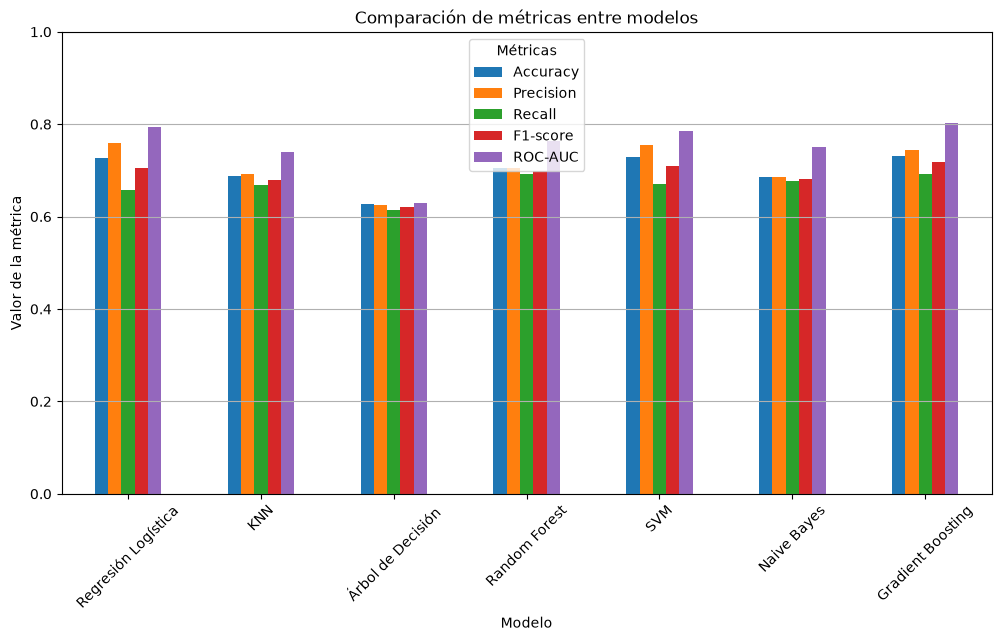

In [27]:
metricas = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

df_resultados.set_index("Modelo")[metricas].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparación de métricas entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.legend(title="Métricas")
plt.show()

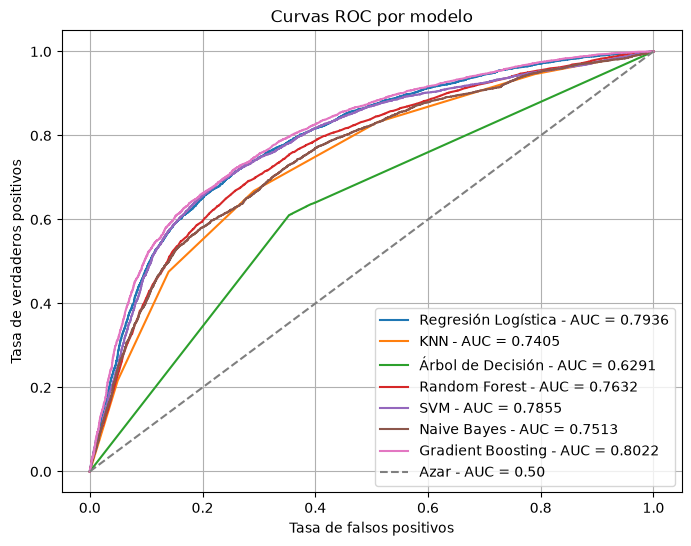

In [31]:
plt.figure(figsize=(8, 6))

for nombre, y_proba in probabilidades_modelos.items():

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_modelo = roc_auc_score(y_test, y_proba)

    plt.plot(
        fpr,
        tpr,
        label=f"{nombre} - AUC = {auc_modelo:.4f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Azar - AUC = 0.50"
)

plt.title("Curvas ROC por modelo")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.grid()
plt.show()

Gradient Boosting presenta el mejor rendimiento general, con el mayor Accuracy, F1-score y ROC-AUC.
Sin embargo, Random Forest obtiene el mejor Recall y la menor cantidad de falsos negativos.
Debido a que el problema está relacionado con riesgo cardiovascular, los falsos negativos son especialmente importantes, por lo que se compararán ambos criterios antes de seleccionar el modelo final.

In [32]:
modelo_base = GradientBoostingClassifier(random_state=42)

param_grid = {
    "modelo__n_estimators": [100, 150, 200],
    "modelo__learning_rate": [0.01, 0.05, 0.1],
    "modelo__max_depth": [2, 3, 4],
    "modelo__subsample": [0.8, 1.0]
}

pipeline_gb = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("modelo", modelo_base)
])

grid_gb = GridSearchCV(
    estimator=pipeline_gb,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__learning_rate': [0.01, 0.05, ...], 'modelo__max_depth': [2, 3, ...], 'modelo__n_estimators': [100, 150, ...], 'modelo__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.S

In [17]:
print("Mejores parámetros:")
print(grid_gb.best_params_)

print("\nMejor F1 en validación cruzada:")
print(grid_gb.best_score_)

Mejores parámetros:
{'modelo__learning_rate': 0.1, 'modelo__max_depth': 3, 'modelo__n_estimators': 200, 'modelo__subsample': 0.8}

Mejor F1 en validación cruzada:
0.7233403631263335


In [18]:
mejor_gb = grid_gb.best_estimator_

y_pred_gb = mejor_gb.predict(X_test)
y_proba_gb = mejor_gb.predict_proba(X_test)[:, 1]

matriz_gb = confusion_matrix(y_test, y_pred_gb)
tn, fp, fn, tp = matriz_gb.ravel()

metricas_gb_opt = pd.DataFrame([{
    "Modelo": "Gradient Boosting Optimizado",
    "Accuracy": accuracy_score(y_test, y_pred_gb),
    "Precision": precision_score(y_test, y_pred_gb, zero_division=0),
    "Recall": recall_score(y_test, y_pred_gb, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_gb, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_gb),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}])

metricas_gb_opt.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Gradient Boosting Optimizado,0.729,0.7436,0.6902,0.7159,0.8024,5321,1616,2104,4687


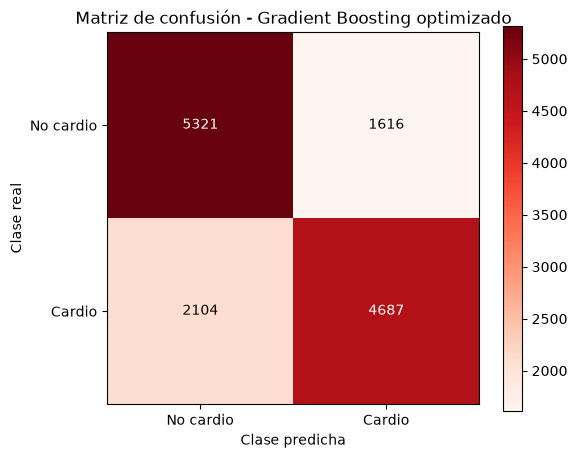

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(matriz_gb, cmap="Reds", interpolation="nearest")
fig.colorbar(im, ax=ax)

ax.set_title("Matriz de confusión - Gradient Boosting optimizado")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["No cardio", "Cardio"])
ax.set_yticklabels(["No cardio", "Cardio"])

for i in range(matriz_gb.shape[0]):
    for j in range(matriz_gb.shape[1]):
        ax.text(
            j,
            i,
            matriz_gb[i, j],
            ha="center",
            va="center",
            color="white" if matriz_gb[i, j] > matriz_gb.max() / 2 else "black"
        )

plt.show()


## Evaluacion de modelos (dataset reducido)

In [33]:
df_reduced = pd.read_csv("cardio_features_reduced.csv")

In [55]:
# ver columnas
df_reduced.columns

Index(['age_years', 'gender', 'height', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'bmi', 'bp_category', 'hypertension',
       'metabolic_risk', 'risk_score', 'cardio'],
      dtype='str')

In [34]:
X_r = df_reduced.drop("cardio", axis=1)
y_r = df_reduced["cardio"]

In [35]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r,
    y_r,
    test_size=0.2,
    random_state=42,
    stratify=y_r
)

In [36]:
columnas_numericas_r = X_r.select_dtypes(include=["int64", "float64"]).columns
columnas_categoricas_r = X_r.select_dtypes(include=["object", "category", "bool"]).columns

C:\Users\igorc\AppData\Local\Temp\ipykernel_14348\1160868288.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas_r = X_r.select_dtypes(include=["object", "category", "bool"]).columns


In [37]:
preprocesamiento_r = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas_r),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas_r)
    ]
)

In [38]:
modelos_r = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [39]:
resultados_r = []
probabilidades_modelos_r = {}

for nombre, modelo in modelos_r.items():

    print("Entrenando:", nombre)

    pipeline_r = Pipeline(steps=[
        ("preprocesamiento", preprocesamiento_r),
        ("modelo", modelo)
    ])

    pipeline_r.fit(X_train_r, y_train_r)

    y_pred_r = pipeline_r.predict(X_test_r)
    y_proba_r = pipeline_r.predict_proba(X_test_r)[:, 1]

    probabilidades_modelos_r[nombre] = y_proba_r

    matriz_r = confusion_matrix(y_test_r, y_pred_r)
    tn, fp, fn, tp = matriz_r.ravel()

    resultados_r.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test_r, y_pred_r),
        "Precision": precision_score(y_test_r, y_pred_r, zero_division=0),
        "Recall": recall_score(y_test_r, y_pred_r, zero_division=0),
        "F1-score": f1_score(y_test_r, y_pred_r, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_r, y_proba_r),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

df_resultados_reduced = pd.DataFrame(resultados_r)

df_resultados_reduced.round(4)

Entrenando: Regresión Logística
Entrenando: KNN
Entrenando: Árbol de Decisión
Entrenando: Random Forest
Entrenando: SVM


c:\Users\igorc\OneDrive\Documentos\ana_cabrera\IA 3er semestre\ADQISICION, ANALISIS Y PROCESAMIENTO DE DATOS\PROYECTO_FINAL_2\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Entrenando: Naive Bayes
Entrenando: Gradient Boosting


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Regresión Logística,0.7276,0.7591,0.6581,0.7050,0.7938,5519,1418,2322,4469
1,KNN,0.6979,0.7010,0.6788,0.6898,0.7448,4971,1966,2181,4610
2,Árbol de Decisión,0.6345,0.6341,0.6174,0.6256,0.6358,4517,2420,2598,4193
3,Random Forest,0.7056,0.7042,0.6981,0.7012,0.7625,4946,1991,2050,4741
4,SVM,0.7286,0.7561,0.6663,0.7084,0.7848,5477,1460,2266,4525
5,Naive Bayes,0.6944,0.6997,0.6697,0.6844,0.7601,4985,1952,2243,4548
6,Gradient Boosting,0.7311,0.7457,0.6927,0.7182,0.8022,5333,1604,2087,4704


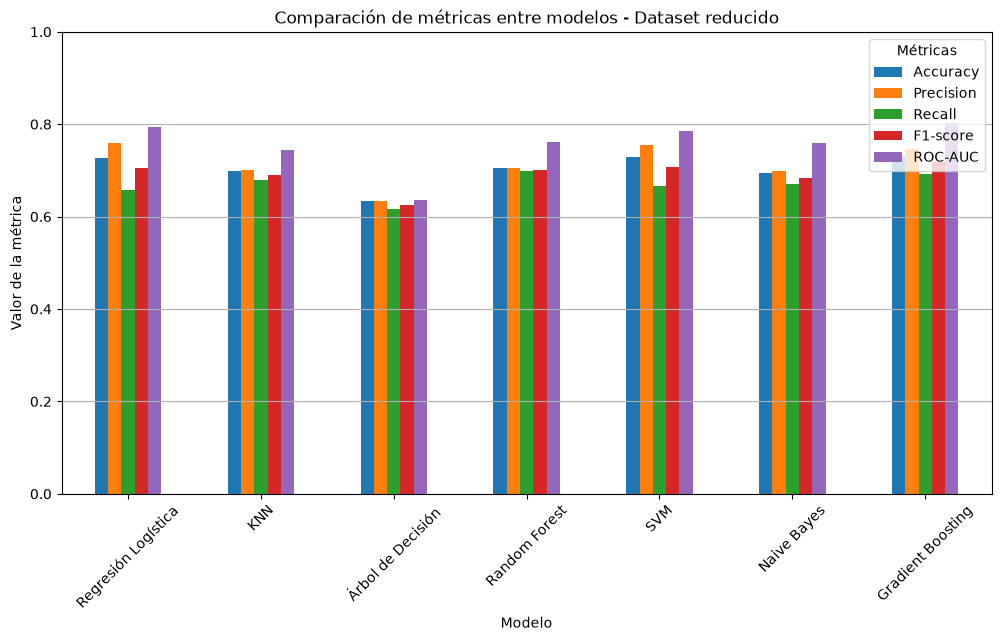

In [40]:
metricas = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

df_resultados_reduced.set_index("Modelo")[metricas].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparación de métricas entre modelos - Dataset reducido")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.legend(title="Métricas")
plt.show()

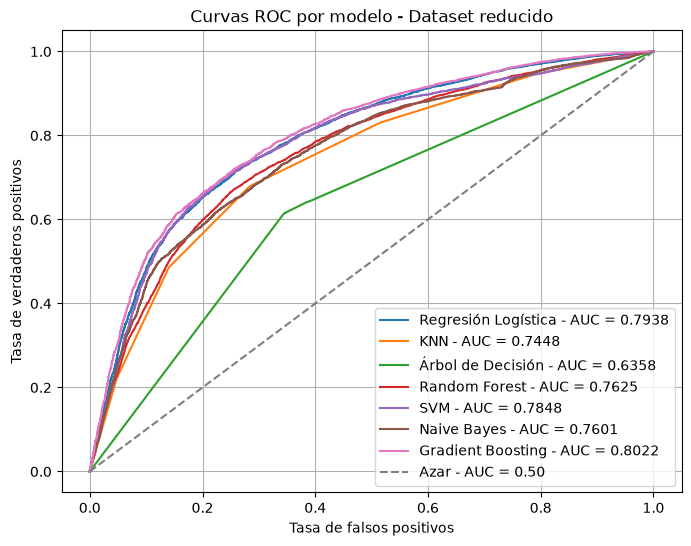

In [41]:
plt.figure(figsize=(8, 6))

for nombre, y_proba_r in probabilidades_modelos_r.items():

    fpr, tpr, _ = roc_curve(y_test_r, y_proba_r)
    auc_modelo = roc_auc_score(y_test_r, y_proba_r)

    plt.plot(
        fpr,
        tpr,
        label=f"{nombre} - AUC = {auc_modelo:.4f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Azar - AUC = 0.50"
)

plt.title("Curvas ROC por modelo - Dataset reducido")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.grid()
plt.show()

In [42]:
# optimizacion de Gradient Boosting en dataset reducido
modelo_gb_r = GradientBoostingClassifier(random_state=42)

param_grid_gb_r = {
    "modelo__n_estimators": [100, 150, 200],
    "modelo__learning_rate": [0.05, 0.1],
    "modelo__max_depth": [2, 3, 4],
    "modelo__subsample": [0.8, 1.0]
}

In [43]:
pipeline_gb_r = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_r),
    ("modelo", modelo_gb_r)
])

In [44]:
grid_gb_r = GridSearchCV(
    estimator=pipeline_gb_r,
    param_grid=param_grid_gb_r,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_gb_r.fit(X_train_r, y_train_r)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__learning_rate': [0.05, 0.1], 'modelo__max_depth': [2, 3, ...], 'modelo__n_estimators': [100, 150, ...], 'modelo__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :re

In [45]:
print("Mejores parámetros:")
print(grid_gb_r.best_params_)

print("\nMejor F1 en validación cruzada:")
print(grid_gb_r.best_score_)

Mejores parámetros:
{'modelo__learning_rate': 0.05, 'modelo__max_depth': 3, 'modelo__n_estimators': 200, 'modelo__subsample': 0.8}

Mejor F1 en validación cruzada:
0.7227656556154722


In [47]:
mejor_gb_r = grid_gb_r.best_estimator_

y_pred_gb_r_opt = mejor_gb_r.predict(X_test_r)
y_proba_gb_r_opt = mejor_gb_r.predict_proba(X_test_r)[:, 1]

matriz_gb_r_opt = confusion_matrix(y_test_r, y_pred_gb_r_opt)

tn, fp, fn, tp = matriz_gb_r_opt.ravel()

metricas_gb_r_opt = pd.DataFrame([{
    "Dataset": "Reducido",
    "Modelo": "Gradient Boosting Optimizado",
    "Accuracy": accuracy_score(y_test_r, y_pred_gb_r_opt),
    "Precision": precision_score(y_test_r, y_pred_gb_r_opt, zero_division=0),
    "Recall": recall_score(y_test_r, y_pred_gb_r_opt, zero_division=0),
    "F1-score": f1_score(y_test_r, y_pred_gb_r_opt, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_r, y_proba_gb_r_opt),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}])

metricas_gb_r_opt.round(4)

,Dataset,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Reducido,Gradient Boosting Optimizado,0.7303,0.7442,0.6928,0.7176,0.8025,5320,1617,2086,4705


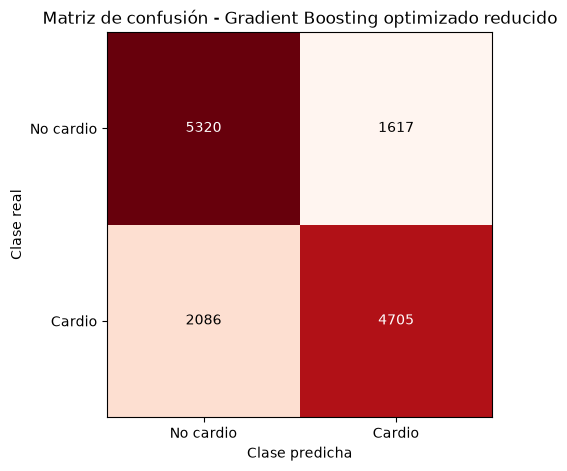

In [50]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(matriz_gb_r_opt,cmap="Reds")

ax.set_title("Matriz de confusión - Gradient Boosting optimizado reducido")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["No cardio", "Cardio"])
ax.set_yticklabels(["No cardio", "Cardio"])

for i in range(matriz_gb_r_opt.shape[0]):
    for j in range(matriz_gb_r_opt.shape[1]):
        ax.text(
            j,
            i,
            matriz_gb_r_opt[i, j],
            ha="center",
            va="center",
            color="white" if matriz_gb[i, j] > matriz_gb.max() / 2 else "black"
        )

plt.show()

In [53]:
# Probar Random Forest optimizado en dataset reducido
modelo_rf_r = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

pipeline_rf_r = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_r),
    ("modelo", modelo_rf_r)
])

pipeline_rf_r.fit(X_train_r, y_train_r)

y_pred_rf_r = pipeline_rf_r.predict(X_test_r)
y_proba_rf_r = pipeline_rf_r.predict_proba(X_test_r)[:, 1]

matriz_rf_r = confusion_matrix(y_test_r, y_pred_rf_r)
tn, fp, fn, tp = matriz_rf_r.ravel()

metricas_rf_r = pd.DataFrame([{
    "Dataset": "Reducido",
    "Modelo": "Random Forest Ajustado",
    "Accuracy": accuracy_score(y_test_r, y_pred_rf_r),
    "Precision": precision_score(y_test_r, y_pred_rf_r, zero_division=0),
    "Recall": recall_score(y_test_r, y_pred_rf_r, zero_division=0),
    "F1-score": f1_score(y_test_r, y_pred_rf_r, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_r, y_proba_rf_r),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}])

metricas_rf_r.round(4)

,Dataset,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Reducido,Random Forest Ajustado,0.7303,0.7494,0.6831,0.7147,0.7993,5386,1551,2152,4639


In [54]:
comparacion_mejoras = pd.concat([
    metricas_gb_r_opt,
    metricas_rf_r
], ignore_index=True)

comparacion_mejoras.round(4)

,Dataset,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Reducido,Gradient Boosting Optimizado,0.7303,0.7442,0.6928,0.7176,0.8025,5320,1617,2086,4705
1,Reducido,Random Forest Ajustado,0.7303,0.7494,0.6831,0.7147,0.7993,5386,1551,2152,4639


## Prueba cambio 1

In [56]:
# ===============================
# FASE 1A - Experimento controlado
# Nuevas variables fisiológicas
# Dataset completo
# ===============================

df_fase1 = df.copy()

df_fase1["pulse_pressure"] = df_fase1["ap_hi"] - df_fase1["ap_lo"]

df_fase1["mean_arterial_pressure"] = (
    (2 * df_fase1["ap_lo"] + df_fase1["ap_hi"]) / 3
)

df_fase1["age_pressure"] = df_fase1["age_years"] * df_fase1["ap_hi"]

X_fase1 = df_fase1.drop("cardio", axis=1)
y_fase1 = df_fase1["cardio"]

In [57]:
X_train_fase1, X_test_fase1, y_train_fase1, y_test_fase1 = train_test_split(
    X_fase1,
    y_fase1,
    test_size=0.2,
    random_state=42,
    stratify=y_fase1
)

In [58]:
columnas_numericas_fase1 = X_fase1.select_dtypes(
    include=["int64", "float64"]
).columns

columnas_categoricas_fase1 = X_fase1.select_dtypes(
    include=["object", "category"]
).columns

print("Numéricas Fase 1:")
print(columnas_numericas_fase1)

print("\nCategóricas Fase 1:")
print(columnas_categoricas_fase1)

Numéricas Fase 1:
Index(['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'obesity',
       'hypertension', 'metabolic_risk', 'lifestyle_risk', 'risk_score',
       'pulse_pressure', 'mean_arterial_pressure', 'age_pressure'],
      dtype='str')

Categóricas Fase 1:
Index(['bmi_category', 'bp_category'], dtype='str')


C:\Users\igorc\AppData\Local\Temp\ipykernel_14348\2499567719.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas_fase1 = X_fase1.select_dtypes(


In [59]:
preprocesamiento_fase1 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas_fase1),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas_fase1)
    ]
)

In [60]:
mejores_parametros_gb = grid_gb.best_params_

params_modelo_gb = {
    key.replace("modelo__", ""): value
    for key, value in mejores_parametros_gb.items()
}

params_modelo_gb

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

In [61]:
modelo_gb_fase1 = GradientBoostingClassifier(
    random_state=42,
    **params_modelo_gb
)

pipeline_gb_fase1 = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_fase1),
    ("modelo", modelo_gb_fase1)
])

In [62]:
pipeline_gb_fase1.fit(X_train_fase1, y_train_fase1)

y_pred_gb_fase1 = pipeline_gb_fase1.predict(X_test_fase1)
y_proba_gb_fase1 = pipeline_gb_fase1.predict_proba(X_test_fase1)[:, 1]

matriz_gb_fase1 = confusion_matrix(y_test_fase1, y_pred_gb_fase1)

tn, fp, fn, tp = matriz_gb_fase1.ravel()

metricas_gb_fase1 = pd.DataFrame([{
    "Modelo": "Gradient Boosting Optimizado + Variables fisiológicas",
    "Accuracy": accuracy_score(y_test_fase1, y_pred_gb_fase1),
    "Precision": precision_score(y_test_fase1, y_pred_gb_fase1, zero_division=0),
    "Recall": recall_score(y_test_fase1, y_pred_gb_fase1, zero_division=0),
    "F1-score": f1_score(y_test_fase1, y_pred_gb_fase1, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_fase1, y_proba_gb_fase1),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}])

metricas_gb_fase1.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Gradient Boosting Optimizado + Variables fisio...,0.7318,0.7478,0.6908,0.7182,0.802,5355,1582,2100,4691


In [63]:
comparacion_fase1 = pd.concat([
    metricas_gb_opt,
    metricas_gb_fase1
], ignore_index=True)

comparacion_fase1.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Gradient Boosting Optimizado,0.7290,0.7436,0.6902,0.7159,0.8024,5321,1616,2104,4687
1,Gradient Boosting Optimizado + Variables fisio...,0.7318,0.7478,0.6908,0.7182,0.8020,5355,1582,2100,4691


In [64]:
# ===============================
# FASE 1B - Probar variables fisiológicas una por una
# ===============================

variables_nuevas = [
    "pulse_pressure",
    "mean_arterial_pressure",
    "age_pressure"
]

resultados_fase1_individual = []

for var_nueva in variables_nuevas:
    
    df_temp = df.copy()
    
    # Crear solo la variable que corresponde
    if var_nueva == "pulse_pressure":
        df_temp["pulse_pressure"] = df_temp["ap_hi"] - df_temp["ap_lo"]
        
    elif var_nueva == "mean_arterial_pressure":
        df_temp["mean_arterial_pressure"] = (
            (2 * df_temp["ap_lo"] + df_temp["ap_hi"]) / 3
        )
        
    elif var_nueva == "age_pressure":
        df_temp["age_pressure"] = df_temp["age_years"] * df_temp["ap_hi"]
    
    X_temp = df_temp.drop("cardio", axis=1)
    y_temp = df_temp["cardio"]
    
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
        X_temp,
        y_temp,
        test_size=0.2,
        random_state=42,
        stratify=y_temp
    )
    
    columnas_numericas_temp = X_temp.select_dtypes(
        include=["int64", "float64"]
    ).columns
    
    columnas_categoricas_temp = X_temp.select_dtypes(
        include=["object", "category"]
    ).columns
    
    preprocesamiento_temp = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), columnas_numericas_temp),
            ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas_temp)
        ]
    )
    
    modelo_temp = GradientBoostingClassifier(
        random_state=42,
        **params_modelo_gb
    )
    
    pipeline_temp = Pipeline(steps=[
        ("preprocesamiento", preprocesamiento_temp),
        ("modelo", modelo_temp)
    ])
    
    pipeline_temp.fit(X_train_temp, y_train_temp)
    
    y_pred_temp = pipeline_temp.predict(X_test_temp)
    y_proba_temp = pipeline_temp.predict_proba(X_test_temp)[:, 1]
    
    matriz_temp = confusion_matrix(y_test_temp, y_pred_temp)
    tn, fp, fn, tp = matriz_temp.ravel()
    
    resultados_fase1_individual.append({
        "Modelo": f"GB Optimizado + {var_nueva}",
        "Accuracy": accuracy_score(y_test_temp, y_pred_temp),
        "Precision": precision_score(y_test_temp, y_pred_temp, zero_division=0),
        "Recall": recall_score(y_test_temp, y_pred_temp, zero_division=0),
        "F1-score": f1_score(y_test_temp, y_pred_temp, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_temp, y_proba_temp),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

df_resultados_fase1_individual = pd.DataFrame(resultados_fase1_individual)

comparacion_fase1_individual = pd.concat([
    metricas_gb_opt,
    df_resultados_fase1_individual,
    metricas_gb_fase1
], ignore_index=True)

comparacion_fase1_individual.round(4)

C:\Users\igorc\AppData\Local\Temp\ipykernel_14348\2398028396.py:44: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas_temp = X_temp.select_dtypes(
C:\Users\igorc\AppData\Local\Temp\ipykernel_14348\2398028396.py:44: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mig

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Gradient Boosting Optimizado,0.7290,0.7436,0.6902,0.7159,0.8024,5321,1616,2104,4687
1,GB Optimizado + pulse_pressure,0.7303,0.7459,0.6897,0.7167,0.8024,5341,1596,2107,4684
2,GB Optimizado + mean_arterial_pressure,0.7311,0.7472,0.6897,0.7173,0.8023,5352,1585,2107,4684
3,GB Optimizado + age_pressure,0.7312,0.7455,0.6933,0.7184,0.8018,5330,1607,2083,4708
4,Gradient Boosting Optimizado + Variables fisio...,0.7318,0.7478,0.6908,0.7182,0.8020,5355,1582,2100,4691


In [65]:
# ===============================
# FASE 1C - Probar combinaciones de 2 variables fisiológicas
# ===============================

from itertools import combinations

variables_nuevas = [
    "pulse_pressure",
    "mean_arterial_pressure",
    "age_pressure"
]

resultados_fase1_combinaciones = []

for combo in combinations(variables_nuevas, 2):
    
    df_temp = df.copy()
    
    # Crear solo las variables de la combinación
    if "pulse_pressure" in combo:
        df_temp["pulse_pressure"] = df_temp["ap_hi"] - df_temp["ap_lo"]
        
    if "mean_arterial_pressure" in combo:
        df_temp["mean_arterial_pressure"] = (
            (2 * df_temp["ap_lo"] + df_temp["ap_hi"]) / 3
        )
        
    if "age_pressure" in combo:
        df_temp["age_pressure"] = df_temp["age_years"] * df_temp["ap_hi"]
    
    X_temp = df_temp.drop("cardio", axis=1)
    y_temp = df_temp["cardio"]
    
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
        X_temp,
        y_temp,
        test_size=0.2,
        random_state=42,
        stratify=y_temp
    )
    
    columnas_numericas_temp = X_temp.select_dtypes(
        include=["int64", "float64"]
    ).columns
    
    columnas_categoricas_temp = X_temp.select_dtypes(
        include=["object", "category"]
    ).columns
    
    preprocesamiento_temp = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), columnas_numericas_temp),
            ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas_temp)
        ]
    )
    
    modelo_temp = GradientBoostingClassifier(
        random_state=42,
        **params_modelo_gb
    )
    
    pipeline_temp = Pipeline(steps=[
        ("preprocesamiento", preprocesamiento_temp),
        ("modelo", modelo_temp)
    ])
    
    pipeline_temp.fit(X_train_temp, y_train_temp)
    
    y_pred_temp = pipeline_temp.predict(X_test_temp)
    y_proba_temp = pipeline_temp.predict_proba(X_test_temp)[:, 1]
    
    matriz_temp = confusion_matrix(y_test_temp, y_pred_temp)
    tn, fp, fn, tp = matriz_temp.ravel()
    
    resultados_fase1_combinaciones.append({
        "Modelo": "GB Optimizado + " + " + ".join(combo),
        "Accuracy": accuracy_score(y_test_temp, y_pred_temp),
        "Precision": precision_score(y_test_temp, y_pred_temp, zero_division=0),
        "Recall": recall_score(y_test_temp, y_pred_temp, zero_division=0),
        "F1-score": f1_score(y_test_temp, y_pred_temp, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_temp, y_proba_temp),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

df_resultados_fase1_combinaciones = pd.DataFrame(resultados_fase1_combinaciones)

comparacion_fase1_completa = pd.concat([
    metricas_gb_opt,
    df_resultados_fase1_individual,
    df_resultados_fase1_combinaciones,
    metricas_gb_fase1
], ignore_index=True)

comparacion_fase1_completa.round(4)

C:\Users\igorc\AppData\Local\Temp\ipykernel_14348\3663070470.py:46: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas_temp = X_temp.select_dtypes(
C:\Users\igorc\AppData\Local\Temp\ipykernel_14348\3663070470.py:46: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mig

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Gradient Boosting Optimizado,0.7290,0.7436,0.6902,0.7159,0.8024,5321,1616,2104,4687
1,GB Optimizado + pulse_pressure,0.7303,0.7459,0.6897,0.7167,0.8024,5341,1596,2107,4684
2,GB Optimizado + mean_arterial_pressure,0.7311,0.7472,0.6897,0.7173,0.8023,5352,1585,2107,4684
3,GB Optimizado + age_pressure,0.7312,0.7455,0.6933,0.7184,0.8018,5330,1607,2083,4708
4,GB Optimizado + pulse_pressure + mean_arterial...,0.7303,0.7472,0.6875,0.7161,0.8017,5357,1580,2122,4669
5,GB Optimizado + pulse_pressure + age_pressure,0.7314,0.7462,0.6927,0.7184,0.8020,5337,1600,2087,4704
6,GB Optimizado + mean_arterial_pressure + age_p...,0.7314,0.7469,0.6914,0.7181,0.8018,5346,1591,2096,4695
7,Gradient Boosting Optimizado + Variables fisio...,0.7318,0.7478,0.6908,0.7182,0.8020,5355,1582,2100,4691


In [66]:
# ===============================
# CIERRE FASE 1
# Dataset provisional con age_pressure
# ===============================

df_fase1_final = df.copy()

df_fase1_final["age_pressure"] = (
    df_fase1_final["age_years"] * df_fase1_final["ap_hi"]
)

X_fase1_final = df_fase1_final.drop("cardio", axis=1)
y_fase1_final = df_fase1_final["cardio"]

df_fase1_final.shape

(68636, 21)

In [67]:
metricas_referencia_fase1 = comparacion_fase1_completa[
    comparacion_fase1_completa["Modelo"] == "GB Optimizado + age_pressure"
].copy()

metricas_referencia_fase1.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
3,GB Optimizado + age_pressure,0.7312,0.7455,0.6933,0.7184,0.8018,5330,1607,2083,4708


In [69]:
[col for col in df_fase1_final.columns if "bmi" in col.lower() or "bp" in col.lower()]

['bmi', 'bmi_category', 'bp_category']

In [72]:
# ===============================
# FASE 2A - Correlación solo con variables numéricas
# ===============================

variables_riesgo = [
    "metabolic_risk",
    "lifestyle_risk",
    "risk_score"
]

variables_contexto_posibles = [
    "age_years",
    "gender",
    "height",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "bmi",
    "bmi_category",
    "obesity",
    "bp_category",
    "hypertension",
    "age_pressure",
    "cardio"
]

# Primero tomamos las que existen en el dataframe
variables_existentes = [
    col for col in variables_contexto_posibles + variables_riesgo
    if col in df_fase1_final.columns
]

# Luego filtramos solo las que son numéricas
variables_numericas_fase2 = [
    col for col in variables_existentes
    if pd.api.types.is_numeric_dtype(df_fase1_final[col])
]

print("Variables existentes:")
print(variables_existentes)

print("\nVariables numéricas usadas para correlación:")
print(variables_numericas_fase2)

Variables existentes:
['age_years', 'gender', 'height', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'bmi_category', 'obesity', 'bp_category', 'hypertension', 'age_pressure', 'cardio', 'metabolic_risk', 'lifestyle_risk', 'risk_score']

Variables numéricas usadas para correlación:
['age_years', 'gender', 'height', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'obesity', 'hypertension', 'age_pressure', 'cardio', 'metabolic_risk', 'lifestyle_risk', 'risk_score']


In [73]:
corr_fase2 = df_fase1_final[variables_numericas_fase2].corr()

variables_riesgo_numericas = [
    col for col in variables_riesgo
    if col in corr_fase2.columns
]

corr_riesgo = corr_fase2.loc[
    variables_riesgo_numericas,
    corr_fase2.columns
]

corr_riesgo.round(3)

,age_years,gender,height,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,obesity,hypertension,age_pressure,cardio,metabolic_risk,lifestyle_risk,risk_score
metabolic_risk,0.129,-0.078,-0.141,0.242,0.205,0.591,0.435,0.000,0.032,-0.004,0.552,0.655,0.116,0.239,0.218,1.000,0.014,0.709
lifestyle_risk,-0.019,0.187,0.116,0.022,0.021,0.010,0.009,0.483,0.369,-0.769,0.001,-0.001,0.015,0.001,0.021,0.014,1.000,0.423
risk_score,0.163,0.046,-0.025,0.382,0.410,0.598,0.523,0.250,0.113,-0.367,0.480,0.539,0.457,0.349,0.267,0.709,0.423,1.000


In [74]:
corr_cardio_fase2 = corr_fase2["cardio"].sort_values(ascending=False)

corr_cardio_fase2.round(4)

cardio            1.0000
ap_hi             0.4281
age_pressure      0.4243
ap_lo             0.3400
risk_score        0.2668
age_years         0.2392
hypertension      0.2363
cholesterol       0.2214
metabolic_risk    0.2178
bmi               0.1887
obesity           0.1550
gluc              0.0896
lifestyle_risk    0.0210
gender            0.0072
alco             -0.0086
height           -0.0115
smoke            -0.0163
active           -0.0376
Name: cardio, dtype: float64

In [75]:
# ===============================
# FASE 2A - Matriz de correlación completa
# Incluye variables numéricas + categóricas codificadas
# ===============================

df_corr_completo = df_fase1_final.copy()

# Convertir variables categóricas a dummies solo para análisis de correlación
df_corr_completo = pd.get_dummies(
    df_corr_completo,
    drop_first=False
)

# Asegurar que todo sea numérico
df_corr_completo = df_corr_completo.astype(float)

# Matriz de correlación completa
corr_completa = df_corr_completo.corr()

corr_completa.round(3)

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,...,risk_score,age_pressure,bmi_category_bajo_peso,bmi_category_normal,bmi_category_obesidad,bmi_category_sobrepeso,bp_category_elevada,bp_category_hipertension_etapa_1,bp_category_hipertension_etapa_2,bp_category_normal
age_years,1.000,-0.023,-0.084,0.055,0.209,0.156,0.155,0.099,-0.048,-0.029,...,0.163,0.763,-0.029,-0.087,0.082,0.019,-0.022,0.027,0.119,-0.170
gender,-0.023,1.000,0.512,0.157,0.062,0.068,-0.037,-0.021,0.339,0.171,...,0.046,0.024,-0.005,0.041,-0.109,0.059,0.003,0.026,0.033,-0.079
height,-0.084,0.512,1.000,0.307,0.020,0.037,-0.053,-0.021,0.194,0.097,...,-0.025,-0.044,0.015,0.112,-0.184,0.053,0.010,0.059,-0.008,-0.082
weight,0.055,0.157,0.307,1.000,0.271,0.253,0.141,0.107,0.067,0.068,...,0.457,0.208,-0.178,-0.586,0.678,0.005,-0.048,-0.016,0.190,-0.181
ap_hi,0.209,0.062,0.020,0.271,1.000,0.734,0.195,0.094,0.028,0.036,...,0.382,0.787,-0.064,-0.198,0.218,0.013,-0.084,-0.192,0.679,-0.508
ap_lo,0.156,0.068,0.037,0.253,0.734,1.000,0.162,0.075,0.025,0.037,...,0.410,0.574,-0.063,-0.181,0.193,0.018,-0.277,-0.056,0.671,-0.578
cholesterol,0.155,-0.037,-0.053,0.141,0.195,0.162,1.000,0.451,0.010,0.035,...,0.598,0.227,-0.021,-0.128,0.155,-0.009,-0.044,-0.055,0.153,-0.082
gluc,0.099,-0.021,-0.021,0.107,0.094,0.075,0.451,1.000,-0.006,0.010,...,0.523,0.125,-0.017,-0.081,0.107,-0.014,-0.019,-0.015,0.067,-0.049
smoke,-0.048,0.339,0.194,0.067,0.028,0.025,0.010,-0.006,1.000,0.340,...,0.250,-0.013,0.009,-0.000,-0.029,0.025,-0.000,-0.008,0.020,-0.012
alco,-0.029,0.171,0.097,0.068,0.036,0.037,0.035,0.010,0.340,1.000,...,0.113,0.005,-0.002,-0.028,0.014,0.016,0.002,-0.017,0.031,-0.014


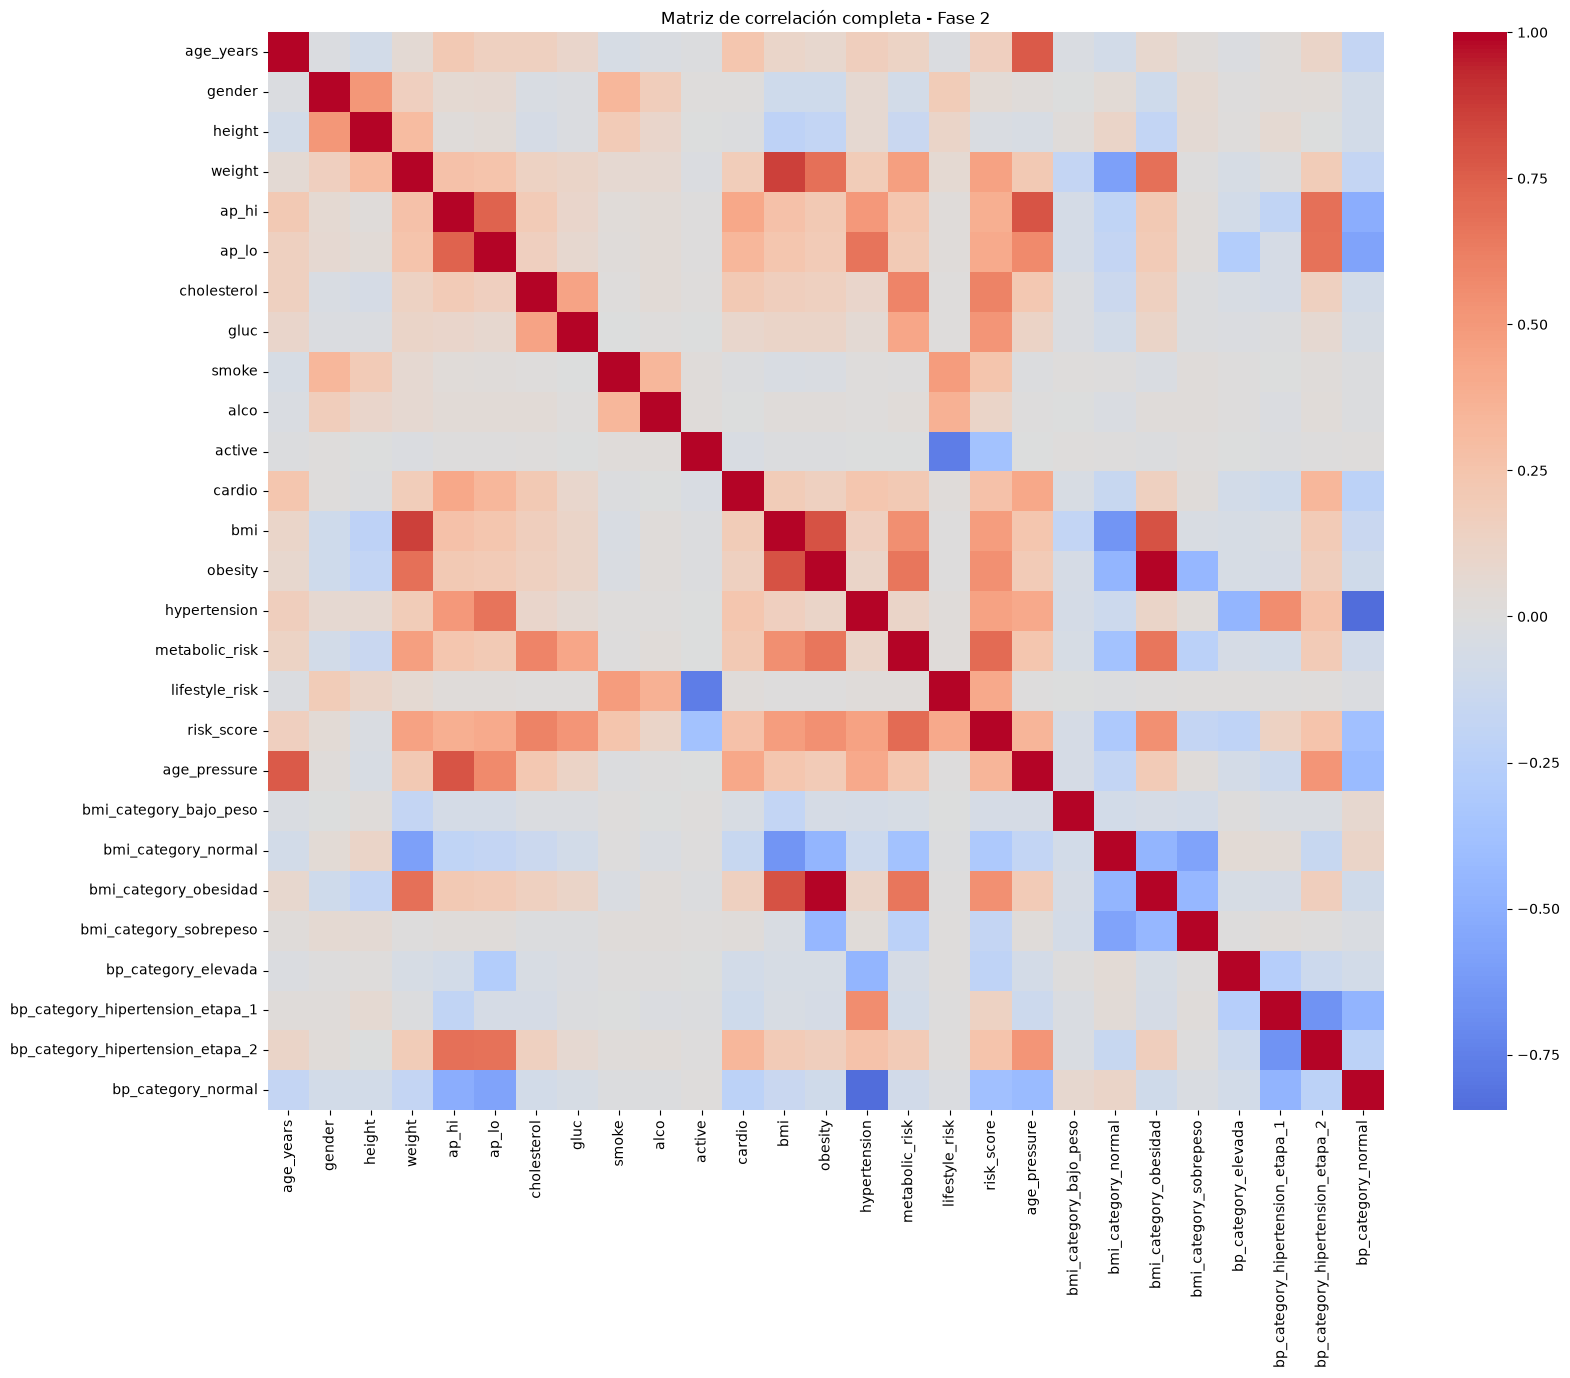

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_completa,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Matriz de correlación completa - Fase 2")
plt.show()

In [77]:
# ===============================
# Correlación de todas las variables con cardio
# ===============================

corr_cardio_completa = corr_completa["cardio"].sort_values(ascending=False)

corr_cardio_completa.round(4)

cardio                              1.0000
ap_hi                               0.4281
age_pressure                        0.4243
bp_category_hipertension_etapa_2    0.3415
ap_lo                               0.3400
risk_score                          0.2668
age_years                           0.2392
hypertension                        0.2363
cholesterol                         0.2214
metabolic_risk                      0.2178
bmi                                 0.1887
weight                              0.1800
obesity                             0.1550
bmi_category_obesidad               0.1550
gluc                                0.0896
lifestyle_risk                      0.0210
bmi_category_sobrepeso              0.0162
gender                              0.0072
alco                               -0.0086
height                             -0.0115
smoke                              -0.0163
active                             -0.0376
bmi_category_bajo_peso             -0.0430
bp_category

In [78]:
corr_cardio_completa.head(20).round(4)

cardio                              1.0000
ap_hi                               0.4281
age_pressure                        0.4243
bp_category_hipertension_etapa_2    0.3415
ap_lo                               0.3400
risk_score                          0.2668
age_years                           0.2392
hypertension                        0.2363
cholesterol                         0.2214
metabolic_risk                      0.2178
bmi                                 0.1887
weight                              0.1800
obesity                             0.1550
bmi_category_obesidad               0.1550
gluc                                0.0896
lifestyle_risk                      0.0210
bmi_category_sobrepeso              0.0162
gender                              0.0072
alco                               -0.0086
height                             -0.0115
Name: cardio, dtype: float64

In [79]:
import numpy as np

corr_abs = corr_completa.abs()

upper = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)

pares_redundantes = (
    upper.stack()
    .reset_index()
    .rename(columns={
        "level_0": "Variable 1",
        "level_1": "Variable 2",
        0: "Correlacion_abs"
    })
    .sort_values("Correlacion_abs", ascending=False)
)

pares_redundantes[
    pares_redundantes["Correlacion_abs"] >= 0.75
].round(4)

,Variable 1,Variable 2,Correlacion_abs
372,obesity,bmi_category_obesidad,1.0000
93,weight,bmi,0.8565
404,hypertension,bp_category_normal,0.8453
345,bmi,bmi_category_obesidad,0.7920
337,bmi,obesity,0.7920
126,ap_hi,age_pressure,0.7868
286,active,lifestyle_risk,0.7688
18,age_years,age_pressure,0.7628


In [81]:
# ===============================
# FASE 2 - Crear pipeline de referencia
# No estamos probando eliminación todavía
# Solo reconstruimos el modelo para leer importancias
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

X_fase2 = df_fase1_final.drop("cardio", axis=1)
y_fase2 = df_fase1_final["cardio"]

X_train_fase2, X_test_fase2, y_train_fase2, y_test_fase2 = train_test_split(
    X_fase2,
    y_fase2,
    test_size=0.2,
    random_state=42,
    stratify=y_fase2
)

columnas_numericas_fase2 = X_fase2.select_dtypes(
    include=["int64", "float64"]
).columns

columnas_categoricas_fase2 = X_fase2.select_dtypes(
    include=["object", "category"]
).columns

preprocesamiento_fase2 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas_fase2),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas_fase2)
    ]
)

params_modelo_gb = {
    key.replace("modelo__", ""): value
    for key, value in grid_gb.best_params_.items()
}

modelo_gb_fase2 = GradientBoostingClassifier(
    random_state=42,
    **params_modelo_gb
)

pipeline_gb_fase2 = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_fase2),
    ("modelo", modelo_gb_fase2)
])

pipeline_gb_fase2.fit(X_train_fase2, y_train_fase2)

C:\Users\igorc\AppData\Local\Temp\ipykernel_14348\96382362.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas_fase2 = X_fase2.select_dtypes(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['age_years','gender','height',...,'lifestyle_risk','risk_score', 'age_pressure']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

In [82]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd

y_pred_fase2 = pipeline_gb_fase2.predict(X_test_fase2)
y_proba_fase2 = pipeline_gb_fase2.predict_proba(X_test_fase2)[:, 1]

matriz_fase2 = confusion_matrix(y_test_fase2, y_pred_fase2)
tn, fp, fn, tp = matriz_fase2.ravel()

metricas_check_fase2 = pd.DataFrame([{
    "Modelo": "GB referencia Fase 2",
    "Accuracy": accuracy_score(y_test_fase2, y_pred_fase2),
    "Precision": precision_score(y_test_fase2, y_pred_fase2),
    "Recall": recall_score(y_test_fase2, y_pred_fase2),
    "F1-score": f1_score(y_test_fase2, y_pred_fase2),
    "ROC-AUC": roc_auc_score(y_test_fase2, y_proba_fase2),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}])

metricas_check_fase2.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,GB referencia Fase 2,0.7312,0.7455,0.6933,0.7184,0.8018,5330,1607,2083,4708


In [83]:
# ===============================
# Importancia interna del Gradient Boosting
# ===============================

import numpy as np
import pandas as pd

preprocesador = pipeline_gb_fase2.named_steps["preprocesamiento"]
modelo = pipeline_gb_fase2.named_steps["modelo"]

num_features = list(preprocesador.transformers_[0][2])
cat_features = list(preprocesador.transformers_[1][2])

if len(cat_features) > 0:
    encoder = preprocesador.named_transformers_["cat"]
    cat_feature_names = list(encoder.get_feature_names_out(cat_features))
else:
    cat_feature_names = []

feature_names = num_features + cat_feature_names

df_importancias = pd.DataFrame({
    "Variable_transformada": feature_names,
    "Importancia": modelo.feature_importances_
}).sort_values("Importancia", ascending=False)

df_importancias.head(30).round(5)

,Variable_transformada,Importancia
4,ap_hi,0.66409
17,age_pressure,0.16067
6,cholesterol,0.06525
11,bmi,0.01954
0,age_years,0.01782
5,ap_lo,0.01514
3,weight,0.01235
14,metabolic_risk,0.01018
2,height,0.00729
7,gluc,0.00697


In [84]:
# ===============================
# Agrupar importancias por variable original
# ===============================

variables_originales = X_fase2.columns.tolist()

def obtener_variable_original(nombre_transformado, variables_originales):
    for var in variables_originales:
        if nombre_transformado == var or nombre_transformado.startswith(var + "_"):
            return var
    return nombre_transformado

df_importancias["Variable_original"] = df_importancias["Variable_transformada"].apply(
    lambda x: obtener_variable_original(x, variables_originales)
)

importancia_agrupada = (
    df_importancias
    .groupby("Variable_original", as_index=False)["Importancia"]
    .sum()
    .sort_values("Importancia", ascending=False)
)

importancia_agrupada.round(5)

,Variable_original,Importancia
4,ap_hi,0.66409
1,age_pressure,0.16067
8,cholesterol,0.06525
6,bmi,0.01998
2,age_years,0.01782
5,ap_lo,0.01514
18,weight,0.01235
14,metabolic_risk,0.01018
11,height,0.00729
10,gluc,0.00697


In [85]:
variables_sospechosas = [
    "risk_score",
    "metabolic_risk",
    "lifestyle_risk",
    "bmi",
    "bmi_category",
    "obesity",
    "bp_category",
    "hypertension",
    "active",
    "ap_hi",
    "ap_lo",
    "age_pressure"
]

importancia_agrupada[
    importancia_agrupada["Variable_original"].isin(variables_sospechosas)
].round(5)

,Variable_original,Importancia
4,ap_hi,0.66409
1,age_pressure,0.16067
6,bmi,0.01998
5,ap_lo,0.01514
14,metabolic_risk,0.01018
16,risk_score,0.00669
0,active,0.00605
7,bp_category,0.00164
13,lifestyle_risk,0.00018
12,hypertension,0.00005


In [86]:
metricas_check_fase2.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,GB referencia Fase 2,0.7312,0.7455,0.6933,0.7184,0.8018,5330,1607,2083,4708


In [87]:
importancia_agrupada.round(5)

,Variable_original,Importancia
4,ap_hi,0.66409
1,age_pressure,0.16067
8,cholesterol,0.06525
6,bmi,0.01998
2,age_years,0.01782
5,ap_lo,0.01514
18,weight,0.01235
14,metabolic_risk,0.01018
11,height,0.00729
10,gluc,0.00697


In [88]:
# ===============================
# FASE 2C - Eliminación controlada de variables con bajo aporte
# ===============================

columnas_eliminar_fase2c = [
    "obesity",
    "hypertension",
    "lifestyle_risk"
]

columnas_eliminar_fase2c = [
    col for col in columnas_eliminar_fase2c
    if col in df_fase1_final.columns
]

df_fase2c = df_fase1_final.drop(columns=columnas_eliminar_fase2c)

print("Columnas eliminadas:")
print(columnas_eliminar_fase2c)

print("\nShape anterior:")
print(df_fase1_final.shape)

print("\nShape nuevo:")
print(df_fase2c.shape)

Columnas eliminadas:
['obesity', 'hypertension', 'lifestyle_risk']

Shape anterior:
(68636, 21)

Shape nuevo:
(68636, 18)


In [89]:
# ===============================
# Entrenar GB optimizado con df_fase2c
# ===============================

X_fase2c = df_fase2c.drop("cardio", axis=1)
y_fase2c = df_fase2c["cardio"]

X_train_fase2c, X_test_fase2c, y_train_fase2c, y_test_fase2c = train_test_split(
    X_fase2c,
    y_fase2c,
    test_size=0.2,
    random_state=42,
    stratify=y_fase2c
)

columnas_numericas_fase2c = X_fase2c.select_dtypes(
    include=["int64", "float64"]
).columns

columnas_categoricas_fase2c = X_fase2c.select_dtypes(
    include=["object", "category"]
).columns

preprocesamiento_fase2c = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas_fase2c),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas_fase2c)
    ]
)

modelo_gb_fase2c = GradientBoostingClassifier(
    random_state=42,
    **params_modelo_gb
)

pipeline_gb_fase2c = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_fase2c),
    ("modelo", modelo_gb_fase2c)
])

pipeline_gb_fase2c.fit(X_train_fase2c, y_train_fase2c)

y_pred_fase2c = pipeline_gb_fase2c.predict(X_test_fase2c)
y_proba_fase2c = pipeline_gb_fase2c.predict_proba(X_test_fase2c)[:, 1]

C:\Users\igorc\AppData\Local\Temp\ipykernel_14348\1715686794.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas_fase2c = X_fase2c.select_dtypes(


In [90]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd

matriz_fase2c = confusion_matrix(y_test_fase2c, y_pred_fase2c)
tn, fp, fn, tp = matriz_fase2c.ravel()

metricas_fase2c = pd.DataFrame([{
    "Modelo": "GB Fase 2C - sin obesity, hypertension, lifestyle_risk",
    "Accuracy": accuracy_score(y_test_fase2c, y_pred_fase2c),
    "Precision": precision_score(y_test_fase2c, y_pred_fase2c, zero_division=0),
    "Recall": recall_score(y_test_fase2c, y_pred_fase2c, zero_division=0),
    "F1-score": f1_score(y_test_fase2c, y_pred_fase2c, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_fase2c, y_proba_fase2c),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}])

comparacion_fase2c = pd.concat([
    metricas_check_fase2,
    metricas_fase2c
], ignore_index=True)

comparacion_fase2c.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,GB referencia Fase 2,0.7312,0.7455,0.6933,0.7184,0.8018,5330,1607,2083,4708
1,"GB Fase 2C - sin obesity, hypertension, lifest...",0.7313,0.7458,0.6930,0.7184,0.8017,5333,1604,2085,4706


In [91]:
# ===============================
# FASE 2D - Eliminación individual: lifestyle_risk
# ===============================

df_fase2d = df_fase1_final.drop(columns=["lifestyle_risk"])

X_fase2d = df_fase2d.drop("cardio", axis=1)
y_fase2d = df_fase2d["cardio"]

X_train_fase2d, X_test_fase2d, y_train_fase2d, y_test_fase2d = train_test_split(
    X_fase2d,
    y_fase2d,
    test_size=0.2,
    random_state=42,
    stratify=y_fase2d
)

columnas_numericas_fase2d = X_fase2d.select_dtypes(
    include=["int64", "float64"]
).columns

columnas_categoricas_fase2d = X_fase2d.select_dtypes(
    include=["object", "category"]
).columns

preprocesamiento_fase2d = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas_fase2d),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas_fase2d)
    ]
)

modelo_gb_fase2d = GradientBoostingClassifier(
    random_state=42,
    **params_modelo_gb
)

pipeline_gb_fase2d = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_fase2d),
    ("modelo", modelo_gb_fase2d)
])

pipeline_gb_fase2d.fit(X_train_fase2d, y_train_fase2d)

y_pred_fase2d = pipeline_gb_fase2d.predict(X_test_fase2d)
y_proba_fase2d = pipeline_gb_fase2d.predict_proba(X_test_fase2d)[:, 1]

matriz_fase2d = confusion_matrix(y_test_fase2d, y_pred_fase2d)
tn, fp, fn, tp = matriz_fase2d.ravel()

metricas_fase2d = pd.DataFrame([{
    "Modelo": "GB Fase 2D - sin lifestyle_risk",
    "Accuracy": accuracy_score(y_test_fase2d, y_pred_fase2d),
    "Precision": precision_score(y_test_fase2d, y_pred_fase2d, zero_division=0),
    "Recall": recall_score(y_test_fase2d, y_pred_fase2d, zero_division=0),
    "F1-score": f1_score(y_test_fase2d, y_pred_fase2d, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_fase2d, y_proba_fase2d),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}])

comparacion_fase2d = pd.concat([
    metricas_check_fase2,
    metricas_fase2d
], ignore_index=True)

comparacion_fase2d.round(4)

C:\Users\igorc\AppData\Local\Temp\ipykernel_14348\1544039574.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas_fase2d = X_fase2d.select_dtypes(


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,GB referencia Fase 2,0.7312,0.7455,0.6933,0.7184,0.8018,5330,1607,2083,4708
1,GB Fase 2D - sin lifestyle_risk,0.7312,0.7460,0.6924,0.7182,0.8016,5336,1601,2089,4702


In [92]:
# ===============================
# FASE 2E - Eliminación individual: obesity
# ===============================

df_fase2e = df_fase1_final.drop(columns=["obesity"])

X_fase2e = df_fase2e.drop("cardio", axis=1)
y_fase2e = df_fase2e["cardio"]

X_train_fase2e, X_test_fase2e, y_train_fase2e, y_test_fase2e = train_test_split(
    X_fase2e,
    y_fase2e,
    test_size=0.2,
    random_state=42,
    stratify=y_fase2e
)

columnas_numericas_fase2e = X_fase2e.select_dtypes(
    include=["int64", "float64"]
).columns

columnas_categoricas_fase2e = X_fase2e.select_dtypes(
    include=["object", "category"]
).columns

preprocesamiento_fase2e = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas_fase2e),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas_fase2e)
    ]
)

modelo_gb_fase2e = GradientBoostingClassifier(
    random_state=42,
    **params_modelo_gb
)

pipeline_gb_fase2e = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_fase2e),
    ("modelo", modelo_gb_fase2e)
])

pipeline_gb_fase2e.fit(X_train_fase2e, y_train_fase2e)

y_pred_fase2e = pipeline_gb_fase2e.predict(X_test_fase2e)
y_proba_fase2e = pipeline_gb_fase2e.predict_proba(X_test_fase2e)[:, 1]

matriz_fase2e = confusion_matrix(y_test_fase2e, y_pred_fase2e)
tn, fp, fn, tp = matriz_fase2e.ravel()

metricas_fase2e = pd.DataFrame([{
    "Modelo": "GB Fase 2E - sin obesity",
    "Accuracy": accuracy_score(y_test_fase2e, y_pred_fase2e),
    "Precision": precision_score(y_test_fase2e, y_pred_fase2e, zero_division=0),
    "Recall": recall_score(y_test_fase2e, y_pred_fase2e, zero_division=0),
    "F1-score": f1_score(y_test_fase2e, y_pred_fase2e, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_fase2e, y_proba_fase2e),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}])

comparacion_fase2e = pd.concat([
    metricas_check_fase2,
    metricas_fase2e
], ignore_index=True)

comparacion_fase2e.round(4)

C:\Users\igorc\AppData\Local\Temp\ipykernel_14348\1340626082.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas_fase2e = X_fase2e.select_dtypes(


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,GB referencia Fase 2,0.7312,0.7455,0.6933,0.7184,0.8018,5330,1607,2083,4708
1,GB Fase 2E - sin obesity,0.7313,0.7459,0.6928,0.7184,0.8020,5334,1603,2086,4705


In [93]:
# ===============================
# FASE 2F - Eliminación individual: hypertension
# ===============================

df_fase2f = df_fase1_final.drop(columns=["hypertension"])

X_fase2f = df_fase2f.drop("cardio", axis=1)
y_fase2f = df_fase2f["cardio"]

X_train_fase2f, X_test_fase2f, y_train_fase2f, y_test_fase2f = train_test_split(
    X_fase2f,
    y_fase2f,
    test_size=0.2,
    random_state=42,
    stratify=y_fase2f
)

columnas_numericas_fase2f = X_fase2f.select_dtypes(
    include=["int64", "float64"]
).columns

columnas_categoricas_fase2f = X_fase2f.select_dtypes(
    include=["object", "category"]
).columns

preprocesamiento_fase2f = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas_fase2f),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas_fase2f)
    ]
)

modelo_gb_fase2f = GradientBoostingClassifier(
    random_state=42,
    **params_modelo_gb
)

pipeline_gb_fase2f = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_fase2f),
    ("modelo", modelo_gb_fase2f)
])

pipeline_gb_fase2f.fit(X_train_fase2f, y_train_fase2f)

y_pred_fase2f = pipeline_gb_fase2f.predict(X_test_fase2f)
y_proba_fase2f = pipeline_gb_fase2f.predict_proba(X_test_fase2f)[:, 1]

matriz_fase2f = confusion_matrix(y_test_fase2f, y_pred_fase2f)
tn, fp, fn, tp = matriz_fase2f.ravel()

metricas_fase2f = pd.DataFrame([{
    "Modelo": "GB Fase 2F - sin hypertension",
    "Accuracy": accuracy_score(y_test_fase2f, y_pred_fase2f),
    "Precision": precision_score(y_test_fase2f, y_pred_fase2f, zero_division=0),
    "Recall": recall_score(y_test_fase2f, y_pred_fase2f, zero_division=0),
    "F1-score": f1_score(y_test_fase2f, y_pred_fase2f, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_fase2f, y_proba_fase2f),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}])

comparacion_fase2f = pd.concat([
    metricas_check_fase2,
    metricas_fase2f
], ignore_index=True)

comparacion_fase2f.round(4)

C:\Users\igorc\AppData\Local\Temp\ipykernel_14348\4085734002.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas_fase2f = X_fase2f.select_dtypes(


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,GB referencia Fase 2,0.7312,0.7455,0.6933,0.7184,0.8018,5330,1607,2083,4708
1,GB Fase 2F - sin hypertension,0.7315,0.7459,0.6934,0.7187,0.8019,5333,1604,2082,4709


In [94]:
# ===============================
# FASE 2 - Dataset actual aceptado
# Se elimina hypertension
# ===============================

df_fase2_actual = df_fase1_final.drop(columns=["hypertension"])

metricas_referencia_fase2 = metricas_fase2f.copy()

metricas_referencia_fase2.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,GB Fase 2F - sin hypertension,0.7315,0.7459,0.6934,0.7187,0.8019,5333,1604,2082,4709


In [95]:
# ===============================
# FASE 2G - Eliminación individual: bp_category
# Partiendo de df_fase2_actual, que ya no tiene hypertension
# ===============================

df_fase2g = df_fase2_actual.drop(columns=["bp_category"])

X_fase2g = df_fase2g.drop("cardio", axis=1)
y_fase2g = df_fase2g["cardio"]

X_train_fase2g, X_test_fase2g, y_train_fase2g, y_test_fase2g = train_test_split(
    X_fase2g,
    y_fase2g,
    test_size=0.2,
    random_state=42,
    stratify=y_fase2g
)

columnas_numericas_fase2g = X_fase2g.select_dtypes(
    include=["int64", "float64"]
).columns

columnas_categoricas_fase2g = X_fase2g.select_dtypes(
    include=["object", "category"]
).columns

preprocesamiento_fase2g = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas_fase2g),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas_fase2g)
    ]
)

modelo_gb_fase2g = GradientBoostingClassifier(
    random_state=42,
    **params_modelo_gb
)

pipeline_gb_fase2g = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_fase2g),
    ("modelo", modelo_gb_fase2g)
])

pipeline_gb_fase2g.fit(X_train_fase2g, y_train_fase2g)

y_pred_fase2g = pipeline_gb_fase2g.predict(X_test_fase2g)
y_proba_fase2g = pipeline_gb_fase2g.predict_proba(X_test_fase2g)[:, 1]

matriz_fase2g = confusion_matrix(y_test_fase2g, y_pred_fase2g)
tn, fp, fn, tp = matriz_fase2g.ravel()

metricas_fase2g = pd.DataFrame([{
    "Modelo": "GB Fase 2G - sin hypertension ni bp_category",
    "Accuracy": accuracy_score(y_test_fase2g, y_pred_fase2g),
    "Precision": precision_score(y_test_fase2g, y_pred_fase2g, zero_division=0),
    "Recall": recall_score(y_test_fase2g, y_pred_fase2g, zero_division=0),
    "F1-score": f1_score(y_test_fase2g, y_pred_fase2g, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_fase2g, y_proba_fase2g),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}])

comparacion_fase2g = pd.concat([
    metricas_referencia_fase2,
    metricas_fase2g
], ignore_index=True)

comparacion_fase2g.round(4)

C:\Users\igorc\AppData\Local\Temp\ipykernel_14348\2076741307.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas_fase2g = X_fase2g.select_dtypes(


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,GB Fase 2F - sin hypertension,0.7315,0.7459,0.6934,0.7187,0.8019,5333,1604,2082,4709
1,GB Fase 2G - sin hypertension ni bp_category,0.7307,0.7451,0.6925,0.7179,0.8017,5328,1609,2088,4703


In [96]:
# ===============================
# Recalcular importancias correctamente
# Modelo actual: sin hypertension
# ===============================

X_actual = df_fase2_actual.drop("cardio", axis=1)
y_actual = df_fase2_actual["cardio"]

X_train_actual, X_test_actual, y_train_actual, y_test_actual = train_test_split(
    X_actual,
    y_actual,
    test_size=0.2,
    random_state=42,
    stratify=y_actual
)

columnas_numericas_actual = X_actual.select_dtypes(
    include=["int64", "float64"]
).columns

columnas_categoricas_actual = X_actual.select_dtypes(
    include=["object", "category"]
).columns

preprocesamiento_actual = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas_actual),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas_actual)
    ]
)

modelo_gb_actual = GradientBoostingClassifier(
    random_state=42,
    **params_modelo_gb
)

pipeline_gb_actual = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_actual),
    ("modelo", modelo_gb_actual)
])

pipeline_gb_actual.fit(X_train_actual, y_train_actual)

C:\Users\igorc\AppData\Local\Temp\ipykernel_14348\1994779634.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas_actual = X_actual.select_dtypes(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['age_years','gender','height',...,'lifestyle_risk','risk_score', 'age_pressure']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

In [97]:
# ===============================
# Importancia corregida agrupada por variable original
# ===============================

preprocesador = pipeline_gb_actual.named_steps["preprocesamiento"]
modelo = pipeline_gb_actual.named_steps["modelo"]

num_features = list(preprocesador.transformers_[0][2])
cat_features = list(preprocesador.transformers_[1][2])

if len(cat_features) > 0:
    encoder = preprocesador.named_transformers_["cat"]
    cat_feature_names = list(encoder.get_feature_names_out(cat_features))
else:
    cat_feature_names = []

feature_names = num_features + cat_feature_names

df_importancias_actual = pd.DataFrame({
    "Variable_transformada": feature_names,
    "Importancia": modelo.feature_importances_
}).sort_values("Importancia", ascending=False)

variables_originales = X_actual.columns.tolist()

# ordenar por longitud para que bmi_category se detecte antes que bmi
variables_originales_ordenadas = sorted(
    variables_originales,
    key=len,
    reverse=True
)

def obtener_variable_original_corregida(nombre_transformado):
    for var in variables_originales_ordenadas:
        if nombre_transformado == var or nombre_transformado.startswith(var + "_"):
            return var
    return nombre_transformado

df_importancias_actual["Variable_original"] = df_importancias_actual[
    "Variable_transformada"
].apply(obtener_variable_original_corregida)

importancia_agrupada_actual = (
    df_importancias_actual
    .groupby("Variable_original", as_index=False)["Importancia"]
    .sum()
    .sort_values("Importancia", ascending=False)
)

importancia_agrupada_actual.round(5)

,Variable_original,Importancia
4,ap_hi,0.66415
1,age_pressure,0.16150
9,cholesterol,0.06548
6,bmi,0.01914
2,age_years,0.01766
5,ap_lo,0.01508
18,weight,0.01296
14,metabolic_risk,0.01010
12,height,0.00702
11,gluc,0.00669


In [98]:
variables_revision = [
    "bmi",
    "bmi_category",
    "obesity",
    "metabolic_risk",
    "risk_score",
    "lifestyle_risk",
    "bp_category",
    "active",
    "ap_hi",
    "ap_lo",
    "age_pressure"
]

importancia_agrupada_actual[
    importancia_agrupada_actual["Variable_original"].isin(variables_revision)
].round(5)

,Variable_original,Importancia
4,ap_hi,0.66415
1,age_pressure,0.16150
6,bmi,0.01914
5,ap_lo,0.01508
14,metabolic_risk,0.01010
16,risk_score,0.00638
0,active,0.00616
8,bp_category,0.00164
7,bmi_category,0.00041
13,lifestyle_risk,0.00033


In [99]:
# ===============================
# FASE 2H - Eliminación individual: bmi_category
# Partiendo de df_fase2_actual
# ===============================

df_fase2h = df_fase2_actual.drop(columns=["bmi_category"])

X_fase2h = df_fase2h.drop("cardio", axis=1)
y_fase2h = df_fase2h["cardio"]

X_train_fase2h, X_test_fase2h, y_train_fase2h, y_test_fase2h = train_test_split(
    X_fase2h,
    y_fase2h,
    test_size=0.2,
    random_state=42,
    stratify=y_fase2h
)

columnas_numericas_fase2h = X_fase2h.select_dtypes(
    include=["int64", "float64"]
).columns

columnas_categoricas_fase2h = X_fase2h.select_dtypes(
    include=["object", "category"]
).columns

preprocesamiento_fase2h = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas_fase2h),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas_fase2h)
    ]
)

modelo_gb_fase2h = GradientBoostingClassifier(
    random_state=42,
    **params_modelo_gb
)

pipeline_gb_fase2h = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_fase2h),
    ("modelo", modelo_gb_fase2h)
])

pipeline_gb_fase2h.fit(X_train_fase2h, y_train_fase2h)

y_pred_fase2h = pipeline_gb_fase2h.predict(X_test_fase2h)
y_proba_fase2h = pipeline_gb_fase2h.predict_proba(X_test_fase2h)[:, 1]

matriz_fase2h = confusion_matrix(y_test_fase2h, y_pred_fase2h)
tn, fp, fn, tp = matriz_fase2h.ravel()

metricas_fase2h = pd.DataFrame([{
    "Modelo": "GB Fase 2H - sin hypertension ni bmi_category",
    "Accuracy": accuracy_score(y_test_fase2h, y_pred_fase2h),
    "Precision": precision_score(y_test_fase2h, y_pred_fase2h, zero_division=0),
    "Recall": recall_score(y_test_fase2h, y_pred_fase2h, zero_division=0),
    "F1-score": f1_score(y_test_fase2h, y_pred_fase2h, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_fase2h, y_proba_fase2h),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}])

comparacion_fase2h = pd.concat([
    metricas_referencia_fase2,
    metricas_fase2h
], ignore_index=True)

comparacion_fase2h.round(4)

C:\Users\igorc\AppData\Local\Temp\ipykernel_14348\2362682744.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas_fase2h = X_fase2h.select_dtypes(


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,GB Fase 2F - sin hypertension,0.7315,0.7459,0.6934,0.7187,0.8019,5333,1604,2082,4709
1,GB Fase 2H - sin hypertension ni bmi_category,0.7315,0.7462,0.6930,0.7186,0.8017,5336,1601,2085,4706


In [100]:
# ===============================
# MODELO ACTUAL DEFINITIVO PARA OPTIMIZAR
# df_fase1_final + age_pressure - hypertension
# ===============================

df_modelo_actual = df_fase1_final.drop(columns=["hypertension"])

X_actual = df_modelo_actual.drop("cardio", axis=1)
y_actual = df_modelo_actual["cardio"]

X_train_actual, X_test_actual, y_train_actual, y_test_actual = train_test_split(
    X_actual,
    y_actual,
    test_size=0.2,
    random_state=42,
    stratify=y_actual
)

columnas_numericas_actual = X_actual.select_dtypes(
    include=["int64", "float64"]
).columns

columnas_categoricas_actual = X_actual.select_dtypes(
    include=["object", "category"]
).columns

preprocesamiento_actual = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas_actual),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas_actual)
    ]
)

C:\Users\igorc\AppData\Local\Temp\ipykernel_14348\481305597.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas_actual = X_actual.select_dtypes(


In [101]:
pipeline_gb_actual = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_actual),
    ("modelo", GradientBoostingClassifier(random_state=42))
])

In [102]:
pipeline_gb_actual = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_actual),
    ("modelo", GradientBoostingClassifier(random_state=42))
])

In [104]:
# ===============================
# GridSearchCV para Gradient Boosting actual
# ===============================

from sklearn.model_selection import GridSearchCV

param_grid_gb_actual = {
    "modelo__n_estimators": [150, 200, 250],
    "modelo__learning_rate": [0.03, 0.05, 0.07, 0.1],
    "modelo__max_depth": [2, 3, 4],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 3, 5],
    "modelo__subsample": [0.8, 0.9, 1.0]
}

grid_gb_actual = GridSearchCV(
    estimator=pipeline_gb_actual,
    param_grid=param_grid_gb_actual,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_gb_actual.fit(X_train_actual, y_train_actual)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits


TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

Detailed tracebacks of the workers should have been printed to stderr in the executor process if faulthandler was not disabled.

In [ ]:
mejor_gb_actual = grid_gb_actual.best_estimator_

print("Mejores parámetros:")
print(grid_gb_actual.best_params_)

print("\nMejor F1 en validación cruzada:")
print(grid_gb_actual.best_score_)